   Experience  Age  Performance  Salary
0           7   39           83  160856
1           4   37           61  108440
2          13   25           91  214016
3          11   49           58  180381
4           8   24           64  146098


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1766 - mae: 0.3610 - val_loss: 0.1236 - val_mae: 0.2932
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1034 - mae: 0.2680 - val_loss: 0.0740 - val_mae: 0.2299
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0619 - mae: 0.2089 - val_loss: 0.0450 - val_mae: 0.1796
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0362 - mae: 0.1583 - val_loss: 0.0249 - val_mae: 0.1311
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0201 - mae: 0.1150 - val_loss: 0.0141 - val_mae: 0.0986
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - mae: 0.0903 - val_loss: 0.0094 - val_mae: 0.0819
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0093 - mae: 0.0786 - val_loss: 0.0072 - val_mae: 0.0708
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0077 - mae: 0.0713 - val_loss: 0.0060 - val_mae: 0.0640
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.00

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


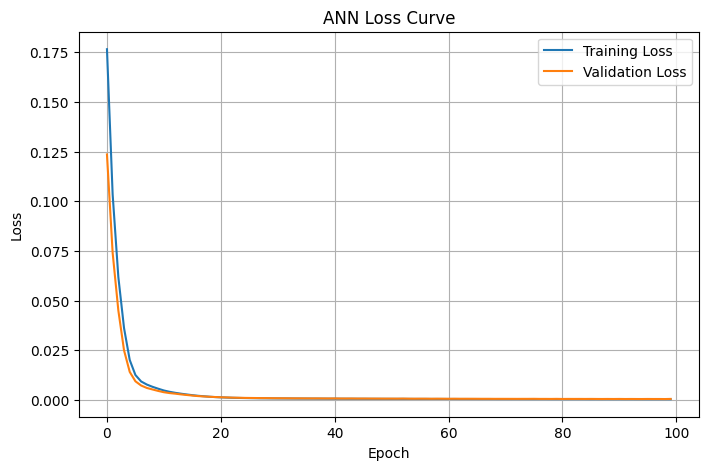

In [7]:
# ====================================================
# EMPLOYEE SALARY PREDICTION USING ANN
# ====================================================

# Import Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# ====================================================
# STEP 1 : CREATE DATASET
# ====================================================

np.random.seed(42)

experience = np.random.randint(1, 15, 1000)
age = np.random.randint(21, 50, 1000)
performance = np.random.randint(50, 100, 1000)

# Salary Formula

salary = (
    experience * 10000 +
    age * 500 +
    performance * 800 +
    np.random.randint(-5000, 5000, 1000)
)

# Create DataFrame

df = pd.DataFrame({
    "Experience": experience,
    "Age": age,
    "Performance": performance,
    "Salary": salary
})

print(df.head())

# ====================================================
# STEP 2 : INPUTS AND OUTPUT
# ====================================================

X = df[["Experience", "Age", "Performance"]]

y = df["Salary"]

# ====================================================
# STEP 3 : TRAIN TEST SPLIT
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================================
# STEP 4 : FEATURE SCALING
# ====================================================

feature_scaler = StandardScaler()

X_train = feature_scaler.fit_transform(X_train)
X_test = feature_scaler.transform(X_test)

# ====================================================
# STEP 5 : SCALE TARGET VARIABLE
# ====================================================

salary_scaler = MinMaxScaler()

y_train = salary_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test = salary_scaler.transform(
    y_test.values.reshape(-1, 1)
)

# ====================================================
# STEP 6 : BUILD ANN MODEL
# ====================================================

model = Sequential([

    Input(shape=(3,)),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        8,
        activation='relu'
    ),

    Dense(
        1
    )

])

# ====================================================
# STEP 7 : COMPILE MODEL
# ====================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ====================================================
# STEP 8 : MODEL SUMMARY
# ====================================================

model.summary()

# ====================================================
# STEP 9 : TRAIN MODEL
# ====================================================

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ====================================================
# STEP 10 : EVALUATE
# ====================================================

loss, mae = model.evaluate(
    X_test,
    y_test
)

print("\nLoss :", loss)
print("MAE  :", mae)

# ====================================================
# STEP 11 : PREDICT NEW EMPLOYEE SALARY
# ====================================================

new_employee = np.array([
    [7, 30, 88]
])

new_employee_scaled = feature_scaler.transform(
    new_employee
)

salary_prediction = model.predict(
    new_employee_scaled
)

# Convert back to actual salary

salary_prediction = salary_scaler.inverse_transform(
    salary_prediction
)

print(
    "\nPredicted Salary : ₹",
    round(salary_prediction[0][0], 2)
)

# ====================================================
# STEP 12 : ACCURACY GRAPH
# ====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("ANN Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()